# Session 2 — Homework solutions

Concise solutions to **HW 1–5** and the final **weekly shop report / optional function**.

The code follows the state of the companion notebook:
- for **HW 5**, the suspicious 580-unit observation has already been marked missing;
- for the **final challenge**, the raw file is reloaded and 580 is repaired to 58.


## Setup


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works whether the CSV is beside the notebook or inside data/.
_candidates = [Path("session2_sales.csv"), Path("data") / "session2_sales.csv"]
DATA_PATH = next((p for p in _candidates if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Put session2_sales.csv beside this notebook or in data/.")

print("Using:", DATA_PATH)


Using: data/session2_sales.csv


## HW 1 — Fraction of days with at least 15 units


In [2]:
stock = np.array([
    [18, 12,  6,  9],
    [21, 10,  8,  7],
    [13, 16,  5, 11],
    [24, 16,  9, 13],
    [ 9, 11,  7, 14],
    [27, 18, 12, 15],
    [22, 13, 10,  6],
])

fraction_busy = (stock >= 15).mean(axis=0)
print(np.round(fraction_busy, 3))
# [coffee, tea, cake, juice] -> [0.714, 0.429, 0.000, 0.143]


[0.714 0.429 0.    0.143]


## HW 2 — Centre each product column


In [3]:
centred = stock - stock.mean(axis=0)

print("shape:", centred.shape)
print("column means:", np.round(centred.mean(axis=0), 12))


shape: (7, 4)
column means: [0. 0. 0. 0.]


## HW 3 — Histogram and mean visitors by shop


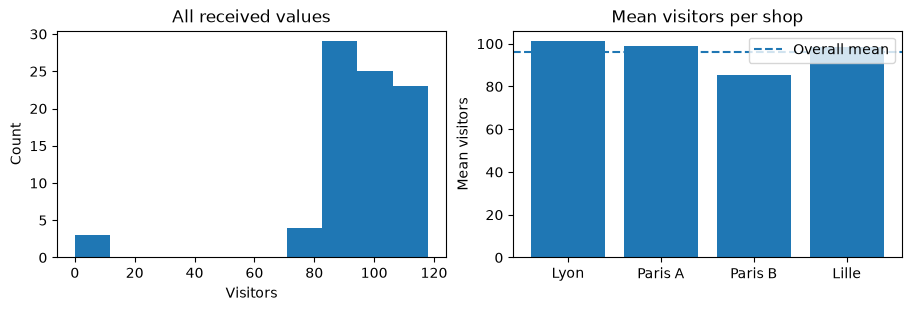

In [4]:
rng = np.random.default_rng(99)
footfall = rng.integers(80, 120, size=(21, 4))
shop_labels = ["Lyon", "Paris A", "Paris B", "Lille"]

received = footfall.copy()
received[11:14, 2] = 0

fig, axes = plt.subplots(1, 2, figsize=(9, 3), layout="constrained")

axes[0].hist(received.ravel())
axes[0].set(xlabel="Visitors", ylabel="Count", title="All received values")

shop_means = received.mean(axis=0)
overall_mean = received.mean()

axes[1].bar(shop_labels, shop_means)
axes[1].axhline(overall_mean, linestyle="--", label="Overall mean")
axes[1].set(ylabel="Mean visitors", title="Mean visitors per shop")
axes[1].legend()

plt.show()


## HW 4 — Missing `units` in the last seven days


In [5]:
sales = pd.read_csv(
    DATA_PATH,
    na_values=["missing"],
    dtype={"shop_id": "string"},
    parse_dates=["date"],
)

latest = sales["date"].max()
start = latest - pd.Timedelta(days=6)

n_missing_last_week = sales.loc[
    sales["date"].between(start, latest), "units"
].isna().sum()

print("Latest date:", latest.date())
print("Missing units in last 7 days:", n_missing_last_week)


Latest date: 2026-04-12
Missing units in last 7 days: 2


## HW 5 — Best date for each product

At this point in the companion notebook, the suspicious value above 300 has already been set to `NaN`. We reproduce that state before grouping.


In [6]:
sales_hw5 = sales.copy()
sales_hw5.loc[sales_hw5["units"] > 300, "units"] = np.nan

best_day = (
    sales_hw5.groupby(["product", "date"])["units"]
             .sum()
             .unstack("date")
             .idxmax(axis=1)
)

print(best_day)


product
cake     2026-03-14
coffee   2026-03-08
tea      2026-03-21
dtype: datetime64[us]


## Final point — Weekly shop report

Reload the raw data, repair the 580 typo to 58, merge the lookup tables, compute revenue, keep known shops, build the weekly table and plot it.


In [7]:
products = pd.DataFrame({
    "product": ["coffee", "tea", "cake"],
    "unit_price": [2.5, 2.0, 3.5],
})

shops = pd.DataFrame({
    "shop_id": ["001", "002", "003", "004"],
    "city": ["Lyon", "Paris", "Paris", "Lille"],
    "region": ["South", "North", "North", "North"],
})

# Steps 1–2: reload and repair.
report_sales = pd.read_csv(
    DATA_PATH,
    na_values=["missing"],
    dtype={"shop_id": "string"},
    parse_dates=["date"],
)

typo = (
    (report_sales["date"] == "2026-03-18")
    & (report_sales["shop_id"] == "002")
    & (report_sales["product"] == "coffee")
)
report_sales.loc[typo, "units"] /= 10

# Step 3: prices and revenue.
known_sales = report_sales.merge(
    products, on="product", how="left", validate="many_to_one"
)
known_sales["revenue"] = known_sales["units"] * known_sales["unit_price"]

# Step 4: shop lookup; count and remove unmatched rows.
known_sales = known_sales.merge(
    shops, on="shop_id", how="left", indicator=True, validate="many_to_one"
)
n_unmatched = (known_sales["_merge"] != "both").sum()
known_sales = known_sales.loc[known_sales["_merge"] == "both"].drop(columns="_merge")

# Step 5: weekly revenue and weekly shares.
known_sales["week"] = known_sales["date"].dt.to_period("W").dt.start_time
weekly = known_sales.pivot_table(
    index="week", columns="shop_id", values="revenue", aggfunc="sum"
)

weekly_array = weekly.to_numpy()
shares = weekly_array / weekly_array.sum(axis=1, keepdims=True)

print("max units after fix:", report_sales["units"].max())
print("unmatched rows:", n_unmatched)
print("weekly shape:", weekly.shape)
print("total revenue:", float(np.nansum(weekly_array)))
print("weekly shares sum to 1:", np.allclose(shares.sum(axis=1), 1))

weekly


max units after fix: 78.0
unmatched rows: 125
weekly shape: (6, 3)
total revenue: 24382.5
weekly shares sum to 1: True


shop_id,001,002,003
week,,,
2026-03-02,1358.5,1689.5,993.0
2026-03-09,1215.5,1681.5,1029.0
2026-03-16,1443.0,1740.0,1106.0
2026-03-23,1385.0,1771.0,577.0
2026-03-30,1385.5,1746.5,1097.0
2026-04-06,1369.0,1772.5,1023.0


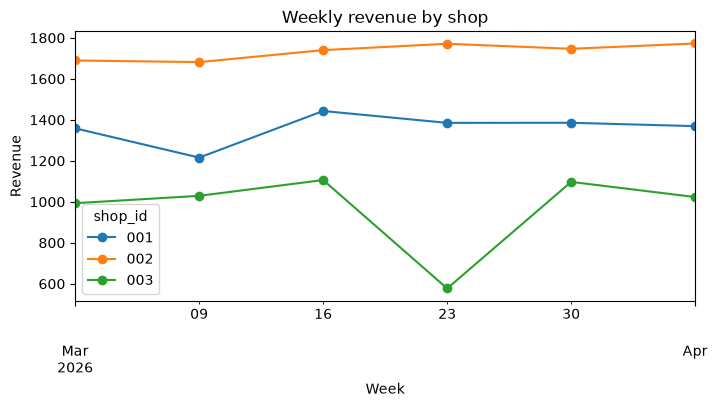

In [8]:
# Step 6: plot one line per known shop.
fig, ax = plt.subplots(figsize=(8, 3.5))
weekly.plot(ax=ax, marker="o")
ax.set(xlabel="Week", ylabel="Revenue", title="Weekly revenue by shop")
ax.legend(title="shop_id")
plt.show()


### Optional homework — Package steps 1–5 into one function


In [9]:
def weekly_report(path: Path) -> pd.DataFrame:
    """Build weekly revenue (weeks × known shops) from the raw sales CSV."""
    sales = pd.read_csv(
        path,
        na_values=["missing"],
        dtype={"shop_id": "string"},
        parse_dates=["date"],
    )

    typo = (
        (sales["date"] == "2026-03-18")
        & (sales["shop_id"] == "002")
        & (sales["product"] == "coffee")
    )
    sales.loc[typo, "units"] /= 10

    sales = sales.merge(products, on="product", how="left", validate="many_to_one")
    sales["revenue"] = sales["units"] * sales["unit_price"]

    sales = sales.merge(
        shops, on="shop_id", how="left", indicator=True, validate="many_to_one"
    )
    sales = sales.loc[sales["_merge"] == "both"].copy()
    sales["week"] = sales["date"].dt.to_period("W").dt.start_time

    return sales.pivot_table(
        index="week", columns="shop_id", values="revenue", aggfunc="sum"
    )


weekly_report(DATA_PATH)


shop_id,001,002,003
week,,,
2026-03-02,1358.5,1689.5,993.0
2026-03-09,1215.5,1681.5,1029.0
2026-03-16,1443.0,1740.0,1106.0
2026-03-23,1385.0,1771.0,577.0
2026-03-30,1385.5,1746.5,1097.0
2026-04-06,1369.0,1772.5,1023.0
